This notebook is for Z->mumu ploting from CMS DoubleMuParked dataset from 2012 in NanoAOD format reduced on muons

In [1]:
from pathlib import Path

import numpy as np
import awkward as ak
import uproot
import vector
import matplotlib.pyplot as plt

vector.register_awkward()

ROOT_FILE = Path("../data/Run2012BC_DoubleMuParked_Muons.root")
assert ROOT_FILE.exists(), f"File not found: {ROOT_FILE.resolve()}"

print(ROOT_FILE.resolve())

C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012BC_DoubleMuParked_Muons.root


In [2]:
f = uproot.open(ROOT_FILE)
events = f["Events"]

print("Number of events:", events.num_entries)

muon_branches = [k for k in events.keys() if "Muon" in k]
muon_branches[:30]

Number of events: 61540413


['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge']

In [3]:
branches = [
    "nMuon",
    "Muon_pt",
    "Muon_eta",
    "Muon_phi",
    "Muon_mass",
    "Muon_charge",
]

arrays = events.arrays(branches, library="ak")

print("Loaded events:", len(arrays["nMuon"]))
print("Example nMuon values:", arrays["nMuon"][:10])

Loaded events: 61540413
Example nMuon values: [2, 2, 1, 4, 4, 3, 2, 2, 2, 2]


In [4]:
muons = ak.zip(
    {
        "pt": arrays["Muon_pt"],
        "eta": arrays["Muon_eta"],
        "phi": arrays["Muon_phi"],
        "mass": arrays["Muon_mass"],
        "charge": arrays["Muon_charge"],
    },
    with_name="Momentum4D",
)

muons[:3]

<MomentumArray4D [[{pt: 10.8, eta: 1.07, ...}, ...], ...] type='3 * var * M...'>

In [5]:
muon_pt_min = 25.0
muon_abs_eta_max = 2.4

selected_muons = muons[
    (muons.pt > muon_pt_min)
    & (np.abs(muons.eta) < muon_abs_eta_max)
]

print("Number of selected muons:", ak.sum(ak.num(selected_muons)))
print("Number of events with >=2 selected muons:", ak.sum(ak.num(selected_muons) >= 2))

Number of selected muons: 24058797
Number of events with >=2 selected muons: 6551110


In [6]:
pairs = ak.combinations(
    selected_muons,
    2,
    fields=["mu1", "mu2"]
)

os_pairs = pairs[
    (pairs.mu1.charge * pairs.mu2.charge) < 0
]

print("Number of opposite-sign dimuon pairs:", ak.sum(ak.num(os_pairs)))

Number of opposite-sign dimuon pairs: 6298854


In [7]:
m_mumu = (os_pairs.mu1 + os_pairs.mu2).mass
m_mumu = ak.flatten(m_mumu)

masses_z = m_mumu[
    (m_mumu > 70)
    & (m_mumu < 110)
]

masses_z = ak.to_numpy(masses_z)

print("Total selected opposite-sign dimuon pairs:", len(masses_z))
print(f"Mean mass: {np.mean(masses_z):.6f}")
print(f"Median mass: {np.median(masses_z):.6f}")

Total selected opposite-sign dimuon pairs: 5307301
Mean mass: 90.120941
Median mass: 90.617180


Saved to ..\figures\cms_mumu_zpeak_70_110GeV.png


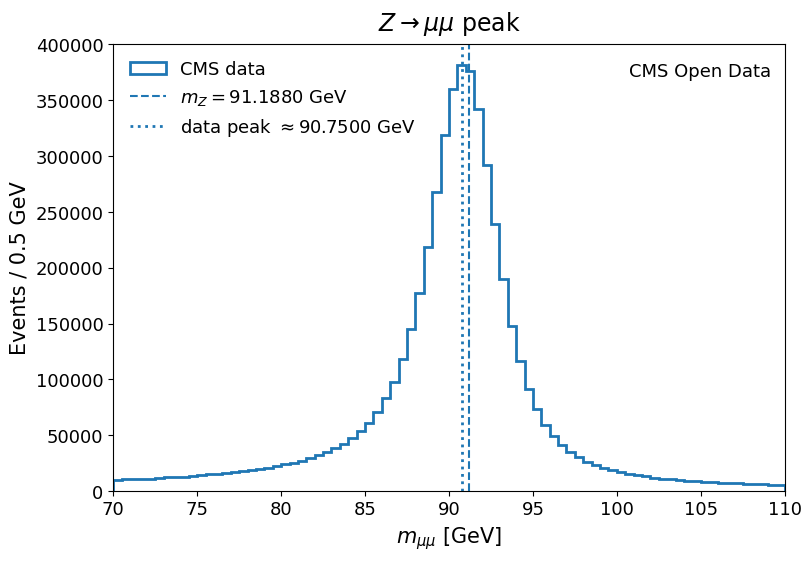

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins = np.linspace(70, 110, 81)
bin_width = bins[1] - bins[0]

counts, edges = np.histogram(masses_z, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
peak_mass = centers[np.argmax(counts)]

ax.hist(
    masses_z,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="CMS data",
)

ax.axvline(
    91.1880,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_Z = 91.1880$ GeV",
)

ax.axvline(
    peak_mass,
    linestyle=":",
    linewidth=2.0,
    label=fr"data peak $\approx {peak_mass:.4f}$ GeV",
)

ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]", fontsize=15)
ax.set_ylabel(f"Events / {bin_width:.1f} GeV", fontsize=15)
ax.set_xlim(70, 110)
ax.tick_params(axis="both", labelsize=13)

ax.set_title(r"$Z\to\mu\mu$ peak", fontsize=17, pad=10)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

out = Path("../figures/cms_mumu_zpeak_70_110GeV.png")
fig.savefig(out, dpi=200)
print(f"Saved to {out}")

Saved to ..\figures\cms_mumu_zpeak_70_110GeV_normalized.png


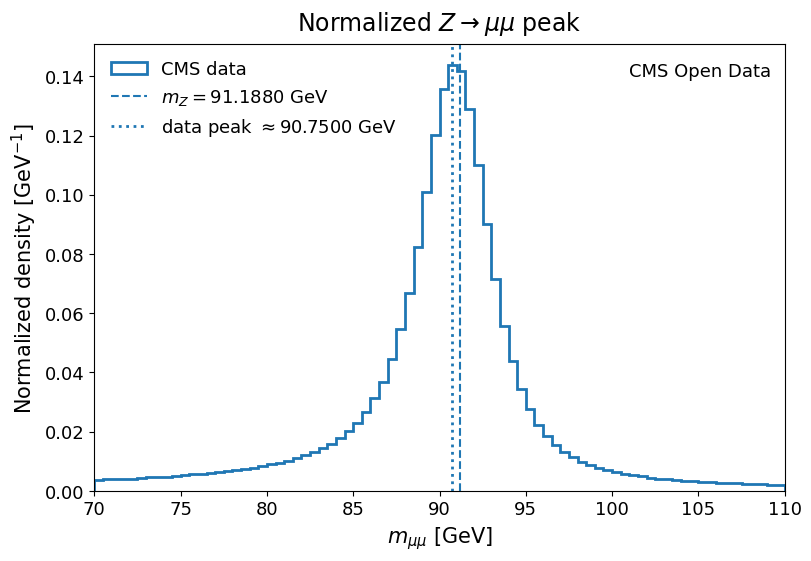

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins = np.linspace(70, 110, 81)

ax.hist(
    masses_z,
    bins=bins,
    histtype="step",
    linewidth=2,
    density=True,
    label="CMS data",
)

ax.axvline(
    91.1880,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_Z = 91.1880$ GeV",
)

ax.axvline(
    peak_mass,
    linestyle=":",
    linewidth=2.0,
    label=fr"data peak $\approx {peak_mass:.4f}$ GeV",
)

ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]", fontsize=15)
ax.set_ylabel(r"Normalized density [GeV$^{-1}$]", fontsize=15)
ax.set_xlim(70, 110)
ax.tick_params(axis="both", labelsize=13)

ax.set_title(r"Normalized $Z\to\mu\mu$ peak", fontsize=17, pad=10)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

out = Path("../figures/cms_mumu_zpeak_70_110GeV_normalized.png")
fig.savefig(out, dpi=200)
print(f"Saved to {out}")

In [10]:
masses_near_z = masses_z[(masses_z > 86) & (masses_z < 96)]

print("Full 70-110 GeV window")
print(f"Mean:   {np.mean(masses_z):.3f} GeV")
print(f"Median: {np.median(masses_z):.3f} GeV")

print("\nNear-Z 86-96 GeV window")
print(f"Mean:   {np.mean(masses_near_z):.3f} GeV")
print(f"Median: {np.median(masses_near_z):.3f} GeV")

Full 70-110 GeV window
Mean:   90.121 GeV
Median: 90.617 GeV

Near-Z 86-96 GeV window
Mean:   90.840 GeV
Median: 90.844 GeV
